In [1]:
dataset_drive_url = (
    "https://drive.google.com/file/d/1qxpRjTCLh5rTJv1jHq3aXIeMxeRW5Eft/view?usp=sharing"
)

In [2]:
import re


def drive_to_direct_url(link: str) -> str:
    """
    Convert Google Drive share link to direct download URL.
    Works for multiple link formats.
    """
    patterns = [
        r'/file/d/([a-zA-Z0-9_-]+)',
        r'id=([a-zA-Z0-9_-]+)',
        r'/open\?id=([a-zA-Z0-9_-]+)'
    ]
    
    file_id = None
    
    for pattern in patterns:
        match = re.search(pattern, link)
        if match:
            file_id = match.group(1)
            break
    
    if not file_id:
        raise ValueError("Invalid Google Drive link")
    
    return f"https://drive.google.com/uc?id={file_id}"

In [3]:
import pandas as pd

df = pd.read_csv(drive_to_direct_url(dataset_drive_url))


In [4]:
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
 14  diabetic                5288 non-null   

In [6]:
df.shape

(5288, 15)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5288.0,45.745651,13.422024,21.00,35.000,45.00,55.0000,80.00
pulse_rate,5288.0,76.626135,12.229319,5.00,69.000,76.00,84.0000,133.00
systolic_bp,5288.0,133.996596,22.231752,62.00,119.000,130.00,147.0000,231.00
diastolic_bp,5288.0,82.229576,12.479007,45.00,73.000,81.00,90.0000,119.00
glucose,5288.0,7.563922,2.944381,0.00,6.000,6.93,8.1300,33.46
height,5288.0,1.548886,0.080328,0.36,1.520,1.55,1.6000,1.96
weight,5288.0,53.644100,10.076059,3.00,46.775,53.00,59.9000,100.70
bmi,5288.0,22.466581,8.819898,1.22,19.620,21.87,24.4725,574.13
family_diabetes,5288.0,0.031959,0.175908,0.00,0.000,0.00,0.0000,1.00
hypertensive,5288.0,0.111006,0.314169,0.00,0.000,0.00,0.0000,1.00


In [8]:
df.columns.tolist()

['age',
 'gender',
 'pulse_rate',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'height',
 'weight',
 'bmi',
 'family_diabetes',
 'hypertensive',
 'family_hypertension',
 'cardiovascular_disease',
 'stroke',
 'diabetic']

In [9]:
df.isnull().sum()

age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64

In [10]:
df.nunique()

age                         60
gender                       2
pulse_rate                  91
systolic_bp                136
diastolic_bp                73
glucose                    937
height                      54
weight                     509
bmi                       1370
family_diabetes              2
hypertensive                 2
family_hypertension          2
cardiovascular_disease       2
stroke                       2
diabetic                     2
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['age',
 'pulse_rate',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'height',
 'weight',
 'bmi',
 'family_diabetes',
 'hypertensive',
 'family_hypertension',
 'cardiovascular_disease',
 'stroke']

In [13]:
df[numerical_cols].head()

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,42,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0
1,35,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0
2,62,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0
3,73,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0
4,68,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0


In [14]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

categorical_cols

['gender', 'diabetic']

In [15]:
continuous_cols = [
    "age",
    "pulse_rate",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "height",
    "weight",
    "bmi"
]

In [16]:
binary_cols = [
    "family_diabetes",
    "hypertensive",
    "family_hypertension",
    "cardiovascular_disease",
    "stroke"
]

In [17]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"Range: {lower:.2f} - {upper:.2f}")
    print()

age: 0 outliers
Range: 5.00 - 85.00

pulse_rate: 96 outliers
Range: 46.50 - 106.50

systolic_bp: 113 outliers
Range: 77.00 - 189.00

diastolic_bp: 54 outliers
Range: 47.50 - 115.50

glucose: 400 outliers
Range: 2.80 - 11.33

height: 193 outliers
Range: 1.40 - 1.72

weight: 79 outliers
Range: 27.09 - 79.59

bmi: 133 outliers
Range: 12.34 - 31.75



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Habib\AppData\Local\Temp\ipykernel_4352\2363214999.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


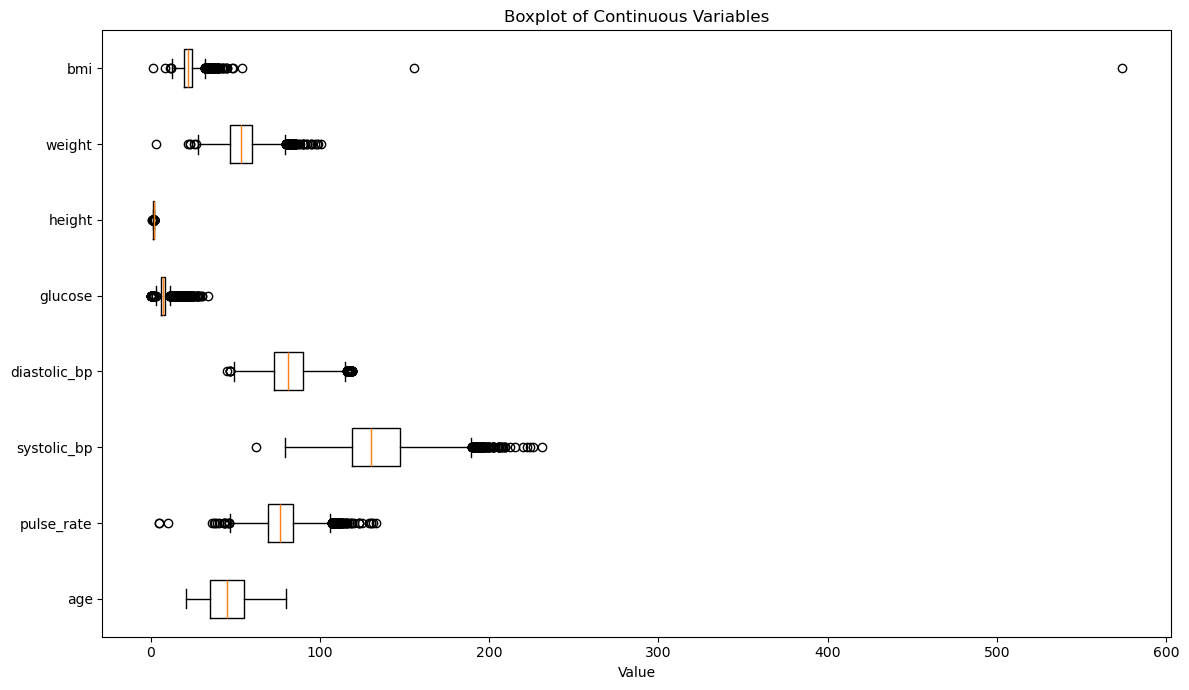

In [19]:
plt.figure(figsize=(12, 7))

plt.boxplot(
    [df[col].dropna() for col in continuous_cols],
    labels=continuous_cols,
    vert=False
)

plt.title("Boxplot of Continuous Variables")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

The `age` column contains no significant outliers. However, several other numerical columns have potential outliers that require careful investigation before deciding whether to retain, modify, or remove them.


In [20]:
df["pulse_rate"].describe()

count    5288.000000
mean       76.626135
std        12.229319
min         5.000000
25%        69.000000
50%        76.000000
75%        84.000000
max       133.000000
Name: pulse_rate, dtype: float64

In [21]:
df[df["pulse_rate"] < 30][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
]

,age,gender,pulse_rate,systolic_bp,diastolic_bp
4812,70,Female,5,120,80
4894,40,Female,10,150,101
4900,60,Female,5,120,60


In [22]:
df = df[df["pulse_rate"] >= 30].copy()

The `pulse_rate` column contains 96 outliers. Its maximum value of 133 is medically plausible, while the minimum value of 5 is medically impossible. Therefore, we set a threshold of 30 and removed the 3 observations with a `pulse_rate` below 30.


In [23]:
df["systolic_bp"].describe()

count    5285.000000
mean      133.998865
std        22.235305
min        62.000000
25%       119.000000
50%       130.000000
75%       147.000000
max       231.000000
Name: systolic_bp, dtype: float64

In [24]:
df[df["systolic_bp"] < 80][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("systolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
2045,60,Female,78,62,51
3425,35,Male,78,79,64


In [25]:
df[df["systolic_bp"] > 200][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("systolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
5019,70,Male,50,201,108
401,46,Female,74,202,106
3895,55,Female,77,202,116
2011,80,Male,75,202,96
5111,55,Male,67,202,114
5071,40,Female,76,202,108
3896,70,Male,75,203,96
4980,65,Female,80,203,114
722,65,Male,91,205,110
1063,65,Male,86,205,119


The `systolic_bp` column contains 113 outliers, with values ranging from 62 to 231 mmHg. Although this range is relatively wide, both the minimum and maximum values can be medically plausible under certain conditions. Therefore, after reviewing the values, no further changes were made to this column.


In [26]:
df["diastolic_bp"].describe()

count    5285.000000
mean       82.230653
std        12.476092
min        45.000000
25%        73.000000
50%        81.000000
75%        90.000000
max       119.000000
Name: diastolic_bp, dtype: float64

In [27]:
df[df["diastolic_bp"] < 50][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("diastolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
3953,47,Male,59,86,45
2387,35,Female,77,87,47
3157,65,Female,73,100,47
4008,43,Female,85,97,47
4014,35,Male,70,148,47
4009,55,Male,78,120,49


In [28]:
df[df["diastolic_bp"] > 115][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("diastolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
627,45,Female,48,209,116
3181,39,Female,69,153,116
2395,50,Female,75,128,116
1889,29,Female,85,180,116
2608,55,Female,73,196,116
4516,65,Male,56,192,116
3877,51,Male,104,177,116
3895,55,Female,77,202,116
4558,35,Female,82,151,116
1572,55,Female,82,191,117


The `diastolic_bp` column contains 54 outliers, with values ranging from 45 to 119 mmHg. Both the minimum and maximum values are medically plausible, so no further changes were made to this column.


In [29]:
df["glucose"].describe()

count    5285.000000
mean        7.559323
std         2.934088
min         0.000000
25%         6.000000
50%         6.930000
75%         8.130000
max        33.460000
Name: glucose, dtype: float64

In [30]:
df[df["glucose"] < 1][
    ["age", "gender", "glucose", "diabetic"]
].sort_values("glucose")

,age,gender,glucose,diabetic
1138,28,Female,0.00,No
4144,30,Female,0.04,No
4718,50,Female,0.08,No
3510,60,Female,0.19,No
5005,49,Female,0.20,No
4209,35,Female,0.26,No
3655,78,Male,0.26,No
3331,60,Female,0.34,No
726,25,Female,0.43,No
1887,30,Female,0.45,No


In [31]:
df = df[df["glucose"] >= 1].copy()

In [32]:
df["glucose"].min()

1.0

The `glucose` column contains 400 outliers, with values ranging from 0 to 33. The lower range contains suspicious values, particularly values below 1, while the maximum value of 33 is within a plausible range. Therefore, we removed observations with `glucose` values below 1.


In [33]:
df["bmi"].describe()

count    5267.000000
mean       22.470264
std         8.835414
min         1.220000
25%        19.630000
50%        21.870000
75%        24.490000
max       574.130000
Name: bmi, dtype: float64

In [34]:
df[df["bmi"] < 12][
    ["age", "gender", "height", "weight", "bmi"]
].sort_values("bmi")

,age,gender,height,weight,bmi
1279,46,Female,1.57,3.0,1.22
1731,70,Male,1.63,21.9,8.29
2392,70,Female,1.42,23.2,11.47


In [35]:
df[df["bmi"] > 50][
    ["age", "gender", "height", "weight", "bmi"]
].sort_values("bmi")

,age,gender,height,weight,bmi
3378,28,Female,1.35,98.0,54.08
885,75,Female,0.64,62.8,155.74
152,24,Male,0.36,72.6,574.13


In [36]:
df = df[(df["bmi"] >= 12) & (df["bmi"] <= 50)].copy()

The `bmi` column contains 133 outliers, with values ranging from 1.22 to 574, both of which are highly suspicious. Based on domain considerations, we set a lower threshold of 12 and an upper threshold of 50 and removed observations with `bmi` values outside this range.

The `height` and `weight` columns were not separately evaluated for outliers because BMI already captures the relationship between height and weight. Including both variables would introduce redundant information. Therefore, the `height` and `weight` columns will be removed from the dataset.


In [37]:
df.drop(columns=["height", "weight"], inplace=True)

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5261.0,45.733131,13.404395,21.0,35.00,45.00,55.00,80.00
pulse_rate,5261.0,76.658240,12.117090,36.0,69.00,76.00,84.00,133.00
systolic_bp,5261.0,133.965786,22.227718,62.0,119.00,130.00,147.00,231.00
diastolic_bp,5261.0,82.224482,12.486174,45.0,73.00,81.00,90.00,119.00
glucose,5261.0,7.581732,2.908396,1.0,6.00,6.93,8.13,33.46
bmi,5261.0,22.342891,4.070210,12.1,19.63,21.87,24.49,48.44
family_diabetes,5261.0,0.031933,0.175839,0.0,0.00,0.00,0.00,1.00
hypertensive,5261.0,0.111006,0.314169,0.0,0.00,0.00,0.00,1.00
family_hypertension,5261.0,0.033644,0.180328,0.0,0.00,0.00,0.00,1.00
cardiovascular_disease,5261.0,0.011405,0.106192,0.0,0.00,0.00,0.00,1.00


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5261 entries, 0 to 5287
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5261 non-null   int64  
 1   gender                  5261 non-null   object 
 2   pulse_rate              5261 non-null   int64  
 3   systolic_bp             5261 non-null   int64  
 4   diastolic_bp            5261 non-null   int64  
 5   glucose                 5261 non-null   float64
 6   bmi                     5261 non-null   float64
 7   family_diabetes         5261 non-null   int64  
 8   hypertensive            5261 non-null   int64  
 9   family_hypertension     5261 non-null   int64  
 10  cardiovascular_disease  5261 non-null   int64  
 11  stroke                  5261 non-null   int64  
 12  diabetic                5261 non-null   object 
dtypes: float64(2), int64(9), object(2)
memory usage: 575.4+ KB


In [40]:
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,17.79,0,0,0,0,0,No


In [41]:
numerical_cols = ["pulse_rate", "systolic_bp", "diastolic_bp", "glucose", "bmi"]

df[numerical_cols].head()

,pulse_rate,systolic_bp,diastolic_bp,glucose,bmi
0,66,110,73,5.88,25.75
1,60,125,68,5.71,19.58
2,57,127,74,6.85,20.24
3,55,193,112,6.28,21.72
4,71,150,81,5.71,17.79


In [42]:
binary_cols = [
    "family_diabetes",
    "hypertensive",
    "family_hypertension",
    "cardiovascular_disease",
    "stroke",
]

df[binary_cols].head()

,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [ ]:
categorical_cols = ["gender", "diabetic"]

df[categorical_cols].head()

,gender,diabetic
0,Female,No
1,Female,No
2,Female,No
3,Male,No
4,Female,No


In [44]:
target_col = "diabetic"



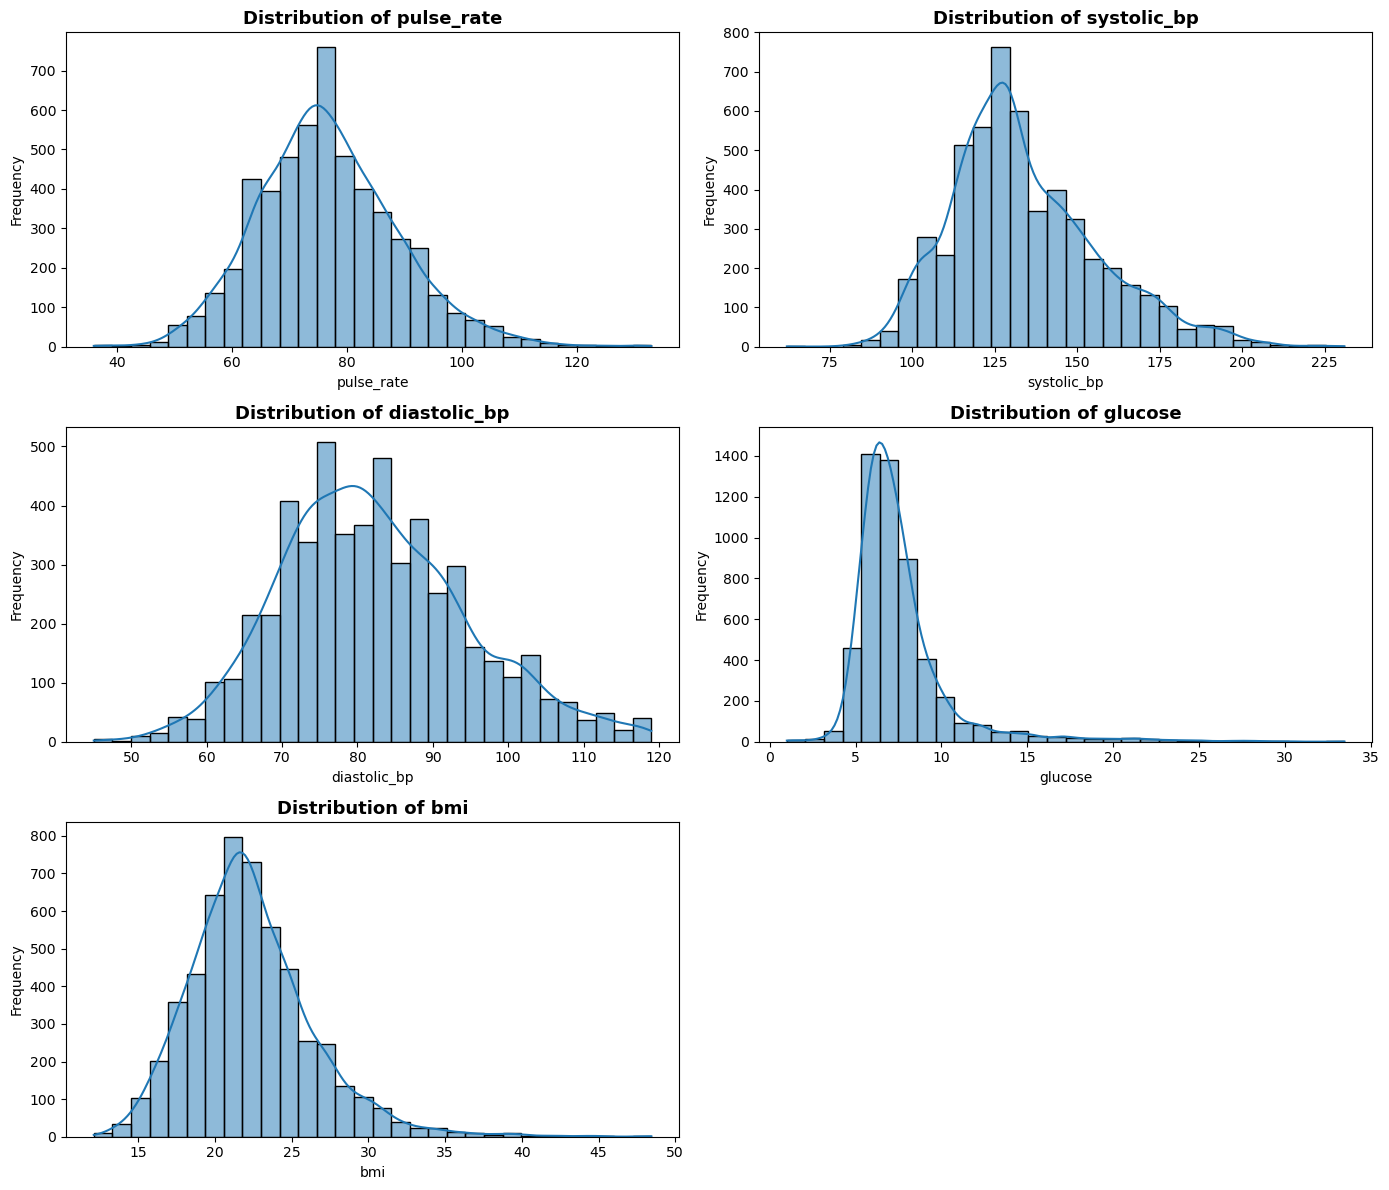

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

    axes[i].set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")


axes[-1].remove()

plt.tight_layout()
plt.show()



The numerical variables show varying degrees of right-skewed distributions. `pulse_rate`, `systolic_bp`, and `diastolic_bp` are relatively concentrated around their central values, with longer tails toward higher values. `glucose` shows the strongest right skew, with most observations concentrated at lower values and a long tail toward higher values. `bmi` is also right-skewed, with most observations concentrated around the lower-middle range. Overall, the distributions are not perfectly normal and generally show a positive (right) skew.


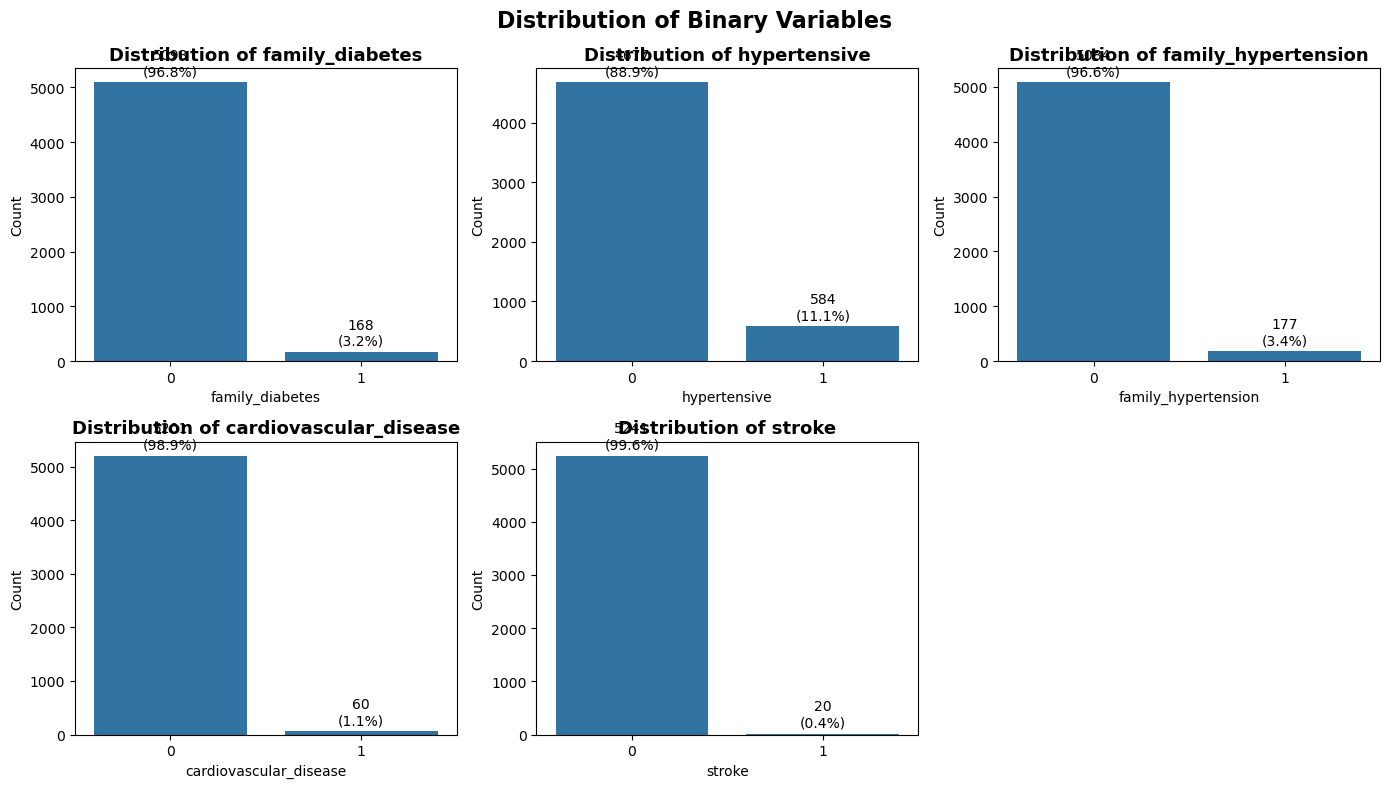

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    ax = axes[i]

    sns.countplot(data=df, x=col, ax=ax)

    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    total = len(df)

    for container in ax.containers:
        labels = [
            f"{int(value)}\n({value / total * 100:.1f}%)"
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3)

axes[-1].remove()

plt.suptitle(
    "Distribution of Binary Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The binary variables show a **highly imbalanced distribution**, with the majority of observations belonging to the `0` class. The `family_diabetes` variable has 96.8% of observations in class 0, followed by `family_hypertension` at 96.6%, `cardiovascular_disease` at 98.9%, `hypertension` at 88.9%, and `stroke` at 99.6%. This indicates a strong class imbalance across all these variables, particularly for `stroke` and `cardiovascular_disease`, where the positive class represents only a very small proportion of the dataset.


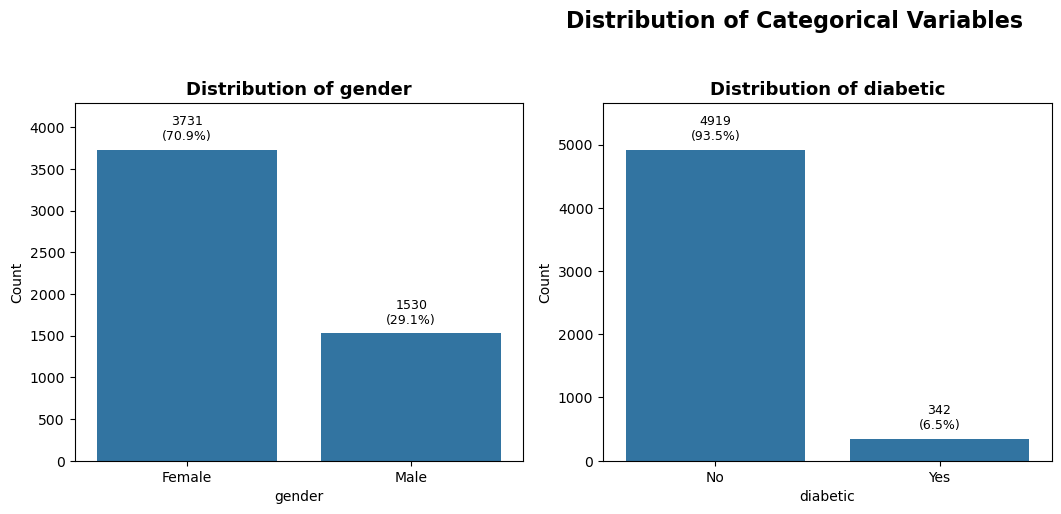

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    sns.countplot(data=df, x=col, ax=ax)

    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    total = len(df)

    for container in ax.containers:
        labels = [
            f"{int(bar.get_height())}\n({bar.get_height() / total * 100:.1f}%)"
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            padding=5,
            fontsize=9,
        )

    ax.margins(y=0.15)


for i in range(len(categorical_cols), len(axes)):
    axes[i].remove()

plt.suptitle("Distribution of Categorical Variables", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The `gender` variable is imbalanced, with females accounting for 70.9% of the observations and males accounting for 29.1%. The target variable, `diabetic`, is highly imbalanced, with 93.5% of the observations belonging to the No diabetes category.